(03-13-equity-premium-puzzle)=

# Mehra-Prescott en Hansen-Jagannathan

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1979–2003: van het werkpapier van Mehra en Prescott (1979, gepubliceerd
in 1985) via Weil (1989) en Hansen en Jagannathan (1991) tot de overzichten van
Kocherlakota, Campbell en Mehra zelf.

**Wat we al weten.** In [](#03-12-consumptie-capm) kreeg de discontovoet een
theorie: $m_{t+1} = \beta (c_{t+1}/c_t)^{-\gamma}$. Hansen en Singleton schatten
de Euler-vergelijking met GMM en vonden dat één paar $(\beta, \gamma)$ de
T-bill en het aandelenrendement niet tegelijk kan prijzen; het aandelenrendement
alleen vroeg een $\gamma$ in de tientallen. Uit [](#00-01-rendementen) weten we
dat het gemiddelde aandelenrendement over een eeuw een standaardfout van bijna
twee procentpunt heeft.

**Welke vraag staat open.** Is de aandelenpremie te groot voor élk redelijk
consumptiemodel — niet alleen voor één econometrische specificatie — en hoe
zeker weten we dat, gegeven hoe slecht die premie gemeten is?
```

## Overzicht

In 1985 publiceerden Rajnish Mehra en Edward Prescott *The Equity Premium: A
Puzzle* {cite}`MehraPrescott1985`. Het paper schat niets. Het bouwt een
Lucas-economie waarvan de consumptiegroei dezelfde gemiddelde waarde, variantie
en autocorrelatie heeft als de Amerikaanse over 1889–1978, laat de
voorkeursparameters vrij binnen grenzen die elke macro-econoom redelijk vindt, en
vraagt welke combinaties van gemiddelde rente en gemiddelde premie de economie
kan voortbrengen. Het antwoord — hooguit 0,35 procentpunt premie, tegen 6,18 in
de data — maakte van een verworpen toets een *puzzel*: een feit dat niet
verdwijnt als je de econometrie verandert. Dat werk definieert het tijdvak omdat
het de vraag verlegt van "past dit model?" naar "welk model zou dit ooit kunnen
passen?".

Epistemisch is dat een kantelpunt. Het consumption CAPM was een
theorie-met-tests; na Mehra en Prescott is de equity premium een
*feit-met-concurrerende-theorieën*. Weil liet in 1989 zien dat het feit een
tweelingbroer heeft, de *risk-free rate puzzle* (risicovrije-rentepuzzel:
waarom is de rente zo laag als beleggers zo ongaarne consumptie over de tijd
verschuiven?) {cite}`Weil1989`. Hansen en Jagannathan vertaalden het in 1991 naar
een grens die voor *elke* stochastic discount factor geldt
{cite}`HansenJagannathan1991`. Santa-Clara vat de uitkomst samen: *"you would
need a coefficient of relative risk aversion in the thirties to justify such a
high premium"* {cite}`SantaClara2026`.

Het toy-voorbeeld is de Markov-keten van Mehra en Prescott, met de hand opgelost
voor $\gamma = 2$ en $\gamma = 10$. De theorie geeft de gesloten oplossing, de
lognormale benadering, de Hansen-Jagannathan-grens met bewijs, de grens voor
meerdere activa en de risicovrije-rentepuzzel. De simulatie rekent de
"toelaatbare regio" na en vraagt hoe zeker de puzzel is als de premie zelf zo
onnauwkeurig gemeten is. De replicatie herberekent tabel 1 van Mehra en Prescott
op Shillers data en tekent de Hansen-Jagannathan-grens voor de markt en de 25
French-portefeuilles, met de consumptie-SDF voor $\gamma = 1, \dots, 50$ erin.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Mehra en Prescott schreven de kern van hun paper in 1979. Mehra vertelde later dat
ze met standaardtheorie uitkwamen op hooguit één procent premie, terwijl de data
over een eeuw consequent zes gaven, en dat het "six more years" kostte om een
sceptisch vak te overtuigen {cite}`Mehra2003`. Waarom was dat zo moeilijk te
geloven?

Een aandeel is riskant omdat het slecht rendeert als het de economie slecht gaat
— als consumptie tegenvalt en een extra euro het meest waard is. De premie is de
prijs voor dat risico, en die hangt af van twee dingen: hoeveel consumptie in
slechte jaren daalt, en hoe erg beleggers dat vinden. Het eerste is gemeten en
klein. Amerikaanse consumptie per hoofd groeide over 1889–1978 met gemiddeld
1,8% per jaar en een standaarddeviatie van 3,6 procentpunt. Een slecht jaar is
een jaar met iets minder groei, niet een jaar waarin het eten op is. Een
verzekering tegen zo'n schommeling is goedkoop, tenzij beleggers er extreem
afkerig van zijn.

Dan het slimme deel van het argument. Stel dat we die extreme afkeer accepteren.
In de standaardvoorkeuren is iemand die schommelingen *tussen toestanden* haat
ook iemand die schommelingen *door de tijd* haat. Consumptie groeit gemiddeld
bijna twee procent per jaar; zo'n belegger wil toekomstige rijkdom naar vandaag
halen door te lenen. Als iedereen dat wil en niemand kan uitlenen, stijgt de rente
tot niemand meer wil lenen — en bij de afkeer die de premie vraagt, ligt die rente
ver boven de tien procent. De werkelijke reële rente was nog geen procent. Je kunt
de premie redden of de rente, niet allebei. Mehra en Prescott zeiden het zelf: de
puzzel is misschien niet waarom de premie zo hoog was, maar waarom de rente zo
laag was.

Fischer Black schreef hun dat een curvatuur van 55 de puzzel zou oplossen
{cite}`MehraPrescott1985`. Dat is de risicoaversie "in de dertig" van
Santa-Clara. Het probleem is niet dat zo'n getal wiskundig onmogelijk is, maar dat
het botst met wat we van mensen weten, en dat het, zoals we zullen zien, alleen
werkt met een geduld-parameter die op een mes balanceert.

Hansen en Jagannathan zagen dat je voor dit argument geen voorkeuren nodig hebt.
Elk prijsmodel is een uitspraak over een discontofactor. Als aandelen per eenheid
risico veel meer opleveren dan obligaties — een Sharpe-ratio van ongeveer 0,4 per
jaar — dan moet die discontofactor wild bewegen, met een schommeling van zo'n
veertig procent per jaar. Een discontofactor gebouwd uit consumptie, die maar een
paar procent schommelt, beweegt alleen zo wild als je hem tot een hoge macht
verheft.

Tot slot de waarschuwing die de lecture meeneemt. De puzzel hangt aan één getal,
de gemiddelde premie, en dat is het slechtst gemeten getal van het vak: 6,18 met
een standaardfout van 1,76. Hoeveel van de puzzel blijft over als de werkelijke
premie drie procent is?

## Toy-voorbeeld: Mehra-Prescott met twee toestanden

We nemen de kalibratie van Mehra en Prescott letterlijk over
{cite}`MehraPrescott1985` (p. 154). Consumptiegroei, en dus dividendgroei van de
boom, neemt twee waarden aan, $g_h = 1 + \mu + \delta$ en $g_l = 1 + \mu - \delta$,
met $\mu = 0{,}018$ en $\delta = 0{,}036$, dus $g_h = 1{,}054$ en $g_l = 0{,}982$.
De overgangsmatrix is symmetrisch met $\phi = 0{,}43$ (de gemeten autocorrelatie
van groei was $-0{,}14$):

| van \ naar | hoog | laag |
|---|---|---|
| hoog | 0{,}43 | 0{,}57 |
| laag | 0{,}57 | 0{,}43 |

De stationaire verdeling is $(\tfrac12, \tfrac12)$. Mehra en Prescott schrijven
$\alpha$, $\lambda_i$ en $w_i$ waar wij $\gamma$, $g_i$ en $\mathrm{PD}_i$
schrijven. We kiezen $\beta = 0{,}99$, de "zeer liberale" waarde van Mehra
{cite}`Mehra2003`.

**Prijs-dividend-ratio's.** De Euler-vergelijking van de boom is die uit
[](#03-12-consumptie-capm): $\mathrm{PD}_i = \sum_j \beta \phi_{ij} g_j^{1-\gamma}(1 + \mathrm{PD}_j)$.
Bij $\gamma = 2$ is $g_h^{-1} = 0{,}948767$ en $g_l^{-1} = 1{,}018330$, dus
$a_{ij} = \beta \phi_{ij} g_j^{-1}$ geeft $a_{hh} = 0{,}403890$,
$a_{hl} = 0{,}574644$, $a_{lh} = 0{,}535389$ en $a_{ll} = 0{,}433503$. Het stelsel
wordt

$$
0{,}596110\,\mathrm{PD}_h - 0{,}574644\,\mathrm{PD}_l = 0{,}978534, \qquad
-0{,}535389\,\mathrm{PD}_h + 0{,}566497\,\mathrm{PD}_l = 0{,}968892 .
$$

De determinant is $0{,}337694 - 0{,}307658 = 0{,}030036$, klein, en daarom rekenen
we met zes decimalen: een ratio van bijna veertig is extreem gevoelig voor de
discontering, net als bij Gordon. Met de regel van Cramer:

$$
\mathrm{PD}_h = \frac{0{,}554337 + 0{,}556768}{0{,}030036} = 36{,}99, \qquad
\mathrm{PD}_l = \frac{0{,}577566 + 0{,}523896}{0{,}030036} = 36{,}67 .
$$

**Aandelenrendement.** $R_{ij} = g_j(1 + \mathrm{PD}_j)/\mathrm{PD}_i$ geeft
$R_{hh} = 1{,}054 \cdot 37{,}99/36{,}99 = 1{,}0825$,
$R_{hl} = 0{,}982 \cdot 37{,}67/36{,}99 = 1{,}0000$, $R_{lh} = 1{,}0920$ en
$R_{ll} = 1{,}0088$. Dus $\E_h[R] = 0{,}43 \cdot 1{,}0825 + 0{,}57 \cdot 1{,}0000 = 1{,}0355$
en $\E_l[R] = 0{,}57 \cdot 1{,}0920 + 0{,}43 \cdot 1{,}0088 = 1{,}0562$.

**Risicovrije rente.** Met $g_h^{-2} = 0{,}900158$ en $g_l^{-2} = 1{,}036996$ kost een
risicovrije eenheid in de hoge toestand
$0{,}99\,(0{,}43 \cdot 0{,}900158 + 0{,}57 \cdot 1{,}036996) = 0{,}968374$, dus
$R^f_h = 1{,}0327$; in de lage toestand
$0{,}99\,(0{,}57 \cdot 0{,}900158 + 0{,}43 \cdot 1{,}036996) = 0{,}949408$, dus
$R^f_l = 1{,}0533$.

**De premie.** Onder de stationaire verdeling is $\E[R] = 1{,}0458$ en
$\E[R^f] = 1{,}0430$: een premie van **0,29 procentpunt** bij een rente van 4,3%.
De data zeggen 6,18 procentpunt bij 0,80%.

Bij $\gamma = 10$ herhalen we de stappen met $g_h^{-9} = 0{,}622923$ en
$g_l^{-9} = 1{,}177597$ (de code doet het rekenwerk). De premie wordt 2,7
procentpunt — beter — maar de gemiddelde rente 13,1%. Het model kan de premie
een eind in de goede richting duwen, maar alleen door de rente absurd te maken.

In [2]:
def mp_economy(gamma, beta, growth, trans):
    """Mehra-Prescott Markov economy with dividend = consumption.

    gamma, beta : scalars or broadcastable arrays (e.g. a meshgrid)
    growth      : (n,) gross growth rate in each state
    trans       : (n, n) transition matrix
    Returns P/D ratios, conditional expected returns and risk-free rates per state,
    their stationary means, and whether the equilibrium exists (spectral radius < 1).
    """
    g = np.asarray(gamma, float)[..., None, None]
    b = np.asarray(beta, float)[..., None, None]
    n = len(growth)
    A = b * trans * growth ** (1 - g)                                  # A_ij = beta phi_ij g_j^(1-gamma)
    exists = np.abs(np.linalg.eigvals(A)).max(axis=-1) < 1
    pd_ratio = np.linalg.solve(np.eye(n) - A, A.sum(axis=-1)[..., None])[..., 0]
    R = growth * (1 + pd_ratio)[..., None, :] / pd_ratio[..., :, None]  # R_ij = g_j (1 + PD_j) / PD_i
    Re = (trans * R).sum(axis=-1)
    Rf = 1 / (b * trans * growth ** (-g)).sum(axis=-1)
    vals, vecs = np.linalg.eig(trans.T)
    pi = np.real(vecs[:, np.argmax(np.real(vals))])
    pi = pi / pi.sum()
    return {"PD": pd_ratio, "Re": Re, "Rf": Rf, "ERe": Re @ pi, "ERf": Rf @ pi, "exists": exists}


growth_mp = np.array([1.054, 0.982])          # 1 + mu +/- delta, Mehra-Prescott (1985, p. 154)
trans_mp = np.array([[0.43, 0.57],
                     [0.57, 0.43]])
beta_toy = 0.99

toy = {}
for gamma_toy in (2, 10):
    eco = mp_economy(gamma_toy, beta_toy, growth_mp, trans_mp)
    toy[f"gamma = {gamma_toy}"] = {
        "PD_h": eco["PD"][0], "PD_l": eco["PD"][1],
        "E_h[R]": eco["Re"][0], "E_l[R]": eco["Re"][1],
        "R^f_h": eco["Rf"][0], "R^f_l": eco["Rf"][1],
        "E[R]": eco["ERe"], "E[R^f]": eco["ERf"],
        "premie (%)": 100 * (eco["ERe"] - eco["ERf"]),
    }

print("met de hand (gamma = 2): PD = 36.99 / 36.67, E[R] = 1.0458, E[R^f] = 1.0430, premie = 0.29%")
pd.DataFrame(toy).T.round(4)

met de hand (gamma = 2): PD = 36.99 / 36.67, E[R] = 1.0458, E[R^f] = 1.0430, premie = 0.29%


,PD_h,PD_l,E_h[R],E_l[R],R^f_h,R^f_l,E[R],E[R^f],premie (%)
gamma = 2,36.9916,36.6706,1.0355,1.0562,1.0327,1.0533,1.0458,1.043,0.2869
gamma = 10,7.7549,7.1762,1.1018,1.2140,1.0772,1.1848,1.1579,1.131,2.6886


De code geeft dezelfde getallen als de handberekening: ratio's van 36,99 en
36,67, een gemiddeld rendement van 1,0458, een rente van 1,0430 en een premie
van 0,29 procentpunt. De tweede rij is wat Mehra en Prescott in 1979 dwarszat: bij
de hoogste risicoaversie die zij redelijk vonden, ligt de rente boven de dertien
procent.

## Theorie

### De economie van Mehra en Prescott

*Waarom zou dit waar zijn?* De Lucas-boom uit [](#03-12-consumptie-capm) prijst
alles wat een functie van consumptie is. Mehra en Prescott maakten één wijziging:
niet het *niveau* maar de *groei* van consumptie volgt een Markov-keten, zodat de
economie een trend heeft en rendementen toch stationair zijn. Omdat CRRA-nut
homothetisch is, schaalt de aandelenprijs met het huidige dividend, en blijft er
een eindig lineair stelsel over.

Groei $x_{t+1} = c_{t+1}/c_t$ neemt waarden $g_1, \dots, g_n$ aan met ergodische
overgangsmatrix $\Phi = (\phi_{ij})$ en stationaire verdeling $\pi = \Phi'\pi$.
Dividend is consumptie; schrijf $p_t = \mathrm{PD}_i\, c_t$ in toestand $i$.

:::{prf:proposition} Gesloten oplossing van de Mehra-Prescott-economie
:label: prf-equity-premium-puzzle-mp

Definieer $\mathbf{A}$ met $a_{ij} = \beta \phi_{ij} g_j^{1-\gamma}$. Als de
spectraalstraal van $\mathbf{A}$ kleiner is dan één, bestaat er een uniek evenwicht
met

```{math}
:label: eq-equity-premium-puzzle-pd
\boldsymbol{\mathrm{PD}} = (\mathbf{I} - \mathbf{A})^{-1}\mathbf{A}\mathbf{1},
\qquad
R_{ij} = \frac{g_j\,(1 + \mathrm{PD}_j)}{\mathrm{PD}_i},
\qquad
R^f_i = \Big(\beta \sum_j \phi_{ij}\, g_j^{-\gamma}\Big)^{-1},
```

en onvoorwaardelijke gemiddelden $\E[R] = \sum_i \pi_i \sum_j \phi_{ij} R_{ij}$
en $\E[R^f] = \sum_i \pi_i R^f_i$.
:::

:::{prf:proof}
Invullen van $p_t = \mathrm{PD}_i c_t$ en $m = \beta g_j^{-\gamma}$ in
$p_t = \E_t[m_{t+1}(p_{t+1} + c_{t+1})]$ en delen door $c_t$ geeft
$\mathrm{PD}_i = \sum_j a_{ij}(1 + \mathrm{PD}_j)$, dus
$(\mathbf{I} - \mathbf{A})\boldsymbol{\mathrm{PD}} = \mathbf{A}\mathbf{1}$. Bij
spectraalstraal kleiner dan één is $(\mathbf{I} - \mathbf{A})^{-1} = \sum_k \mathbf{A}^k$
niet-negatief en de oplossing uniek en positief; dit is de voorwaarde
$\lim \mathbf{A}^m = 0$ van Mehra en Prescott (p. 151), de eindige versie van
[](#thm-consumptie-capm-contractie). Het rendement volgt uit
$R_{ij} = (p_{t+1} + c_{t+1})/p_t$ met $c_{t+1} = g_j c_t$, de rente uit
$1/R^f_i = \E_i[m]$. Ergodiciteit maakt tijdgemiddelden gelijk aan gemiddelden
onder $\pi$. $\square$
:::

Mehra en Prescott kalibreerden $\mu$, $\delta$ en $\phi$ op de gemiddelde groei,
de standaarddeviatie en de autocorrelatie van consumptie over 1889–1978 (1,83%,
3,57 en $-0{,}14$ in hun tabel 1). Ze beperkten $\gamma$ tot hooguit tien, op
grond van micro- en macro-bewijs dat ze uitvoerig citeren, en $\beta$ tot
$(0, 1)$. Over die verzameling tekenden ze de paren
$(\E[R^f], \E[R] - \E[R^f])$ met een rente tussen nul en vier procent als
"admissible region" (hun figuur 4). De conclusie (p. 156): *"The largest premium
obtainable with the model is 0.35 percent, which is not close to the observed
value."* De gemiddelde rente was 0,80% en de premie 6,18% (SE 1,76). Andere
groeiprocessen veranderden daar weinig aan: met vier toestanden stijgt het
maximum naar 0,39% (p. 160), en de premie schaalt ruwweg met $\delta^2$.

### De lognormale benadering: waarom de premie klein is

*Waarom zou dit waar zijn?* Volgens [](#thm-consumptie-capm-beta) is de premie
$\gamma$ maal de covariantie van het rendement met consumptiegroei. In de
Lucas-boom is het dividend consumptie, dus is die covariantie de variantie van
consumptiegroei — en die is klein.

Met lognormale iid groei, $\Delta c_{t+1} = \log x_{t+1} \sim N(\mu_x, \sigma_x^2)$,
geeft [](#eq-consumptie-capm-lognormaal) met leverage één exact

```{math}
:label: eq-equity-premium-puzzle-lognormaal
\log \E[R] - \log R^f = \gamma\, \Cov(\Delta c, \log R) = \gamma\,\sigma_x^2,
\qquad
\log R^f = -\log\beta + \gamma\mu_x - \tfrac12\gamma^2\sigma_x^2 .
```

Voor een aandeel dat niet perfect met consumptie correleert, is
$\E[R^e] \approx \gamma\,\Cov(\Delta c, r)$, dus nog kleiner. Mehra (2003,
p. 13–15) zet tabel 1 om naar $\sigma_x^2 = \log(1 + 0{,}036^2/1{,}018^2) = 0{,}00125$
en $\mu_x = 0{,}0172$. Bij $\gamma = 10$ is de log-premie ongeveer 1,3
procentpunt; voor 6,18 is $\gamma \approx 48$ nodig. Met de werkelijke correlatie
wordt het getal groter. Campbell rapporteert beide versies: de risicoaversie uit
de gemeten covariantie en die bij een correlatie van één. Voor de Amerikaanse
jaardata 1891–1994 is dat 20,9 respectievelijk 10,4, voor de naoorlogse
kwartaaldata 1947.2–1996.3 246,6 respectievelijk 47,6 (tabel 5 in het werkpapier
NBER 6485) {cite}`Campbell1999`.

### De Hansen-Jagannathan-grens

*Waarom zou dit waar zijn?* Een excess rendement — lang in aandelen, kort in de
obligatie — kost niets, dus de SDF moet het op nul waarderen. Met een positief
gemiddelde lukt dat alleen als het slecht betaalt precies wanneer de SDF hoog is.
Hoe groter het gemiddelde ten opzichte van de spreiding, hoe harder de SDF moet
schommelen. Er is geen voorkeur of evenwicht voor nodig: alleen $p = \E[mx]$ en
Cauchy-Schwarz.

:::{prf:theorem} Hansen-Jagannathan-grens (één excess rendement)
:label: thm-equity-premium-puzzle-hj

Laat $m$ een SDF zijn met $\E[m] > 0$ en eindige variantie, en $R^e$ een excess
rendement met eindige variantie waarvoor $\E[m R^e] = 0$. Dan geldt

```{math}
:label: eq-equity-premium-puzzle-hj
\frac{\sigma(m)}{\E[m]} \;\ge\; \frac{|\E[R^e]|}{\sigma(R^e)} .
```

Omdat dit voor elk excess rendement geldt, mag de rechterkant de hoogste
haalbare Sharpe-ratio zijn.
:::

:::{prf:proof}
Uit $0 = \E[mR^e] = \E[m]\,\E[R^e] + \Cov(m, R^e)$ volgt
$\E[m]\,|\E[R^e]| = |\Cov(m, R^e)|$. Cauchy-Schwarz op de gecentreerde variabelen
geeft $|\Cov(m, R^e)| \le \sigma(m)\,\sigma(R^e)$. Dus
$\E[m]\,|\E[R^e]| \le \sigma(m)\,\sigma(R^e)$; deel door $\E[m]\,\sigma(R^e) > 0$.
Gelijkheid geldt alleen als $m$ lineair is in $R^e$ met negatieve helling. $\square$
:::

Met $\E[m] = 1/R^f \approx 1$ zegt de grens dat de jaarlijkse standaarddeviatie
van de SDF minstens de Sharpe-ratio van de markt is. Mehra (2003, p. 17) rekent die
op 0,37. In de lognormale consumptie-economie is $\sigma(m)/\E[m] \approx \gamma\sigma_x$,
dus haalt bij $\sigma_x = 0{,}036$ pas $\gamma \approx 10$ de grens, en dat bij een
correlatie van één. Hansen en Jagannathan tekenden dit in hun figuur 1 (p. 228) op
jaardata 1891–1985: de consumptie-SDF met $\beta = 0{,}95$ en $\gamma$ van nul tot
dertig (bij hen met omgekeerd teken) valt pas "for large $|\gamma|$" in de
toegestane regio.

In [3]:
def sdf_moments_chain(gamma, beta, growth=growth_mp):
    """Unconditional mean and std of m = beta g^(-gamma) when next-period growth is 50/50."""
    values = beta * growth ** (-gamma)
    return values.mean(), values.std()

rows = {}
for gamma_val in (2, 10, 25):
    mean_m, sd_m = sdf_moments_chain(gamma_val, beta_toy)
    rows[gamma_val] = {"E[m]": mean_m, "sigma(m)": sd_m, "sigma(m)/E[m]": sd_m / mean_m,
                       "impliciete R^f - 1": 1 / mean_m - 1}
print(f"Sharpe-ratio van de premie 1889-1978 (Mehra-Prescott, tabel 1): {6.18 / 16.67:.3f}")
pd.DataFrame(rows).T.rename_axis("gamma").round(4)

Sharpe-ratio van de premie 1889-1978 (Mehra-Prescott, tabel 1): 0.371


,E[m],sigma(m),sigma(m)/E[m],impliciete R^f - 1
gamma,,,,
2,0.9589,0.0677,0.0706,0.0429
10,0.8861,0.3010,0.3397,0.1285
25,0.9124,0.6466,0.7086,0.0960


In de Mehra-Prescott-keten schommelt de SDF bij $\gamma = 2$ zeven procent, een
vijfde van wat de grens eist. Bij $\gamma = 10$ komt de verhouding met 0,34 in de
buurt van 0,37, maar het gemiddelde van de SDF is dan 0,89 — een rente van bijna
13%. Bij $\gamma = 25$ is de grens ruim gehaald en de rente nog steeds bijna tien
procent. De grens is noodzakelijk, niet voldoende; wie hem niet haalt, kan de
data niet prijzen, wat het model verder ook doet.

### De grens met meerdere activa: een frontier van SDF's

*Waarom zou dit waar zijn?* Meer activa betekent meer excess rendementen, dus meer
eisen aan de SDF, en de scherpste komt van de beste combinatie. Zonder risicovrij
activum ligt $\E[m]$ niet vast, en hoort bij elke kandidaat-waarde een minimale
$\sigma(m)$. Die minimale SDF is, net als de minimum-variantie-portefeuille van
[](#01-04-markowitz), een lineaire combinatie van de rendementen.

Laat $\mathbf{R}$ een vector van $N$ bruto rendementen zijn met gemiddelde
$\boldsymbol{\mu}$ en niet-singuliere covariantiematrix $\boldsymbol{\Sigma}$.

:::{prf:theorem} Hansen-Jagannathan-frontier
:label: thm-equity-premium-puzzle-frontier

Voor elke SDF $m$ met $\E[m\mathbf{R}] = \mathbf{1}$ en $\E[m] = v$ geldt

```{math}
:label: eq-equity-premium-puzzle-frontier
\sigma^2(m) \;\ge\; \sigma^2(m^*_v) = (\mathbf{1} - v\boldsymbol{\mu})'\,
\boldsymbol{\Sigma}^{-1}\,(\mathbf{1} - v\boldsymbol{\mu}),
\qquad
m^*_v = v + (\mathbf{1} - v\boldsymbol{\mu})'\boldsymbol{\Sigma}^{-1}(\mathbf{R} - \boldsymbol{\mu}),
```

en $m^*_v$ zelf voldoet aan $\E[m^*_v\mathbf{R}] = \mathbf{1}$ en $\E[m^*_v] = v$.
:::

:::{prf:proof}
Uit $\E[m\mathbf{R}] = \mathbf{1}$ en $\E[m] = v$ volgt
$\Cov(m, \mathbf{R}) = \mathbf{1} - v\boldsymbol{\mu}$, voor elke toegestane $m$
dezelfde vector. Voor $m^*_v$ is $\E[m^*_v] = v$ en
$\Cov(m^*_v, \mathbf{R}) = \boldsymbol{\Sigma}\boldsymbol{\Sigma}^{-1}(\mathbf{1} - v\boldsymbol{\mu})$,
dus $m^*_v$ is toegestaan. Schrijf $m = m^*_v + e$; dan is $\E[e] = 0$ en
$\Cov(e, \mathbf{R}) = \mathbf{0}$. Omdat $m^*_v - v$ lineair is in
$\mathbf{R} - \boldsymbol{\mu}$, is ook $\Cov(e, m^*_v) = 0$, en dus
$\sigma^2(m) = \sigma^2(m^*_v) + \sigma^2(e) \ge \sigma^2(m^*_v)$. Invullen geeft de
kwadratische vorm. $\square$
:::

De grens is de spiegeling van de mean-variance-frontier van de rendementen. Zit er
een (bijna) risicovrij activum in $\mathbf{R}$, dan wordt de grens een smalle V
rond $v = 1/R^f$: een SDF met een ander gemiddelde prijst dat activum verkeerd,
hoe volatiel hij ook is. Hansen en Jagannathan eisten in een tweede stap ook dat
$m$ positief is, wat de grens aanscherpt (hun sectie IV); wij gebruiken de
eenvoudige versie uit `hap.stats.hansen_jagannathan_bound`, een ondergrens op een
ondergrens.

```{warning}
De grens gebruikt geschatte $\boldsymbol{\mu}$ en $\boldsymbol{\Sigma}$. Met $N$
activa en $T$ waarnemingen is de maximale Sharpe-ratio in de steekproef
systematisch te hoog — dezelfde overfitting als de in-sample-frontier van
Markowitz. Met 25 portefeuilles en negentig jaarwaarnemingen is de geschatte
grens veel hoger dan de ware.
```

### Waarom de rente de uitweg afsluit

*Waarom zou dit waar zijn?* Met CRRA-nut is $\gamma$ zowel de afkeer van
schommelingen tussen toestanden als die van schommelingen door de tijd. Een hoge
$\gamma$ om de premie te redden, maakt beleggers ook zeer onwillig om te sparen
terwijl consumptie groeit; om ze tevreden te houden met de groei die er is, moet
de rente hoog zijn — of hun geduld onwaarschijnlijk groot.

Zonder onzekerheid, bij constante groei $x$, geeft de Euler-vergelijking
$1 = \beta x^{-\gamma} R^f$, dus

```{math}
:label: eq-equity-premium-puzzle-eis
\log R^f = -\log\beta + \gamma \log x
\quad\Longrightarrow\quad
\frac{\partial \log x}{\partial \log R^f} = \frac{1}{\gamma} \equiv \psi .
```

De *elasticity of intertemporal substitution* (EIS, intertemporele
substitutie-elasticiteit: hoeveel procent de consumptiegroei verandert per
procentpunt rente) is $1/\gamma$. Met onzekerheid komt de voorzorgsterm uit
[](#eq-equity-premium-puzzle-lognormaal) erbij: $\gamma\mu_x$ is de leenwens,
$-\tfrac12\gamma^2\sigma_x^2$ het voorzorgssparen, dat pas bij zeer grote $\gamma$
wint. Zet het resultaat gelijk aan de gemeten rente en los op naar de benodigde
$\beta$.

In [4]:
Ex, sd_x, Rf_obs = 1.018, 0.036, 1.008                   # Mehra-Prescott 1889-1978 (Mehra 2003, table 4)
s2_x = np.log(1 + sd_x**2 / Ex**2)
mu_x = np.log(Ex) - s2_x / 2

gammas_rf = np.array([0.5, 1, 2, 5, 10, 13.8, 20, 27.1, 30, 40, 47.6])
beta_needed = np.exp(-np.log(Rf_obs) + gammas_rf * mu_x - 0.5 * gammas_rf**2 * s2_x)
roots = (mu_x + np.array([-1, 1]) * np.sqrt(mu_x**2 - 2 * s2_x * np.log(Rf_obs))) / s2_x

print(f"sigma_x^2 = {s2_x:.5f}, mu_x = {mu_x:.4f}")
print(f"beta < 1 alleen voor gamma < {roots[0]:.2f} of gamma > {roots[1]:.1f}")
pd.DataFrame({"gamma": gammas_rf, "benodigde beta": beta_needed}).set_index("gamma").T.round(3)

sigma_x^2 = 0.00125, mu_x = 0.0172
beta < 1 alleen voor gamma < 0.47 of gamma > 27.1


gamma,0.5,1.0,2.0,5.0,10.0,13.8,20.0,27.1,30.0,40.0,47.6
benodigde beta,1.0,1.009,1.024,1.064,1.107,1.117,1.09,1.0,0.948,0.727,0.546


Dit is de risicovrije-rentepuzzel van Weil in één regel. Voor een reële rente van
0,8% is voor elke $\gamma$ tussen ongeveer een half en 27 een $\beta$ *groter dan
één* nodig: beleggers moeten de toekomst zwaarder wegen dan het heden. Pas boven
$\gamma \approx 27$ drukt het voorzorgsmotief de rente weer omlaag, en bij
$\gamma = 47{,}6$ hoort $\beta = 0{,}55$ — de combinatie waarmee Mehra (2003,
p. 15–16) 1889–1978 exact reproduceert en die hij een "knife edge" noemt
(oefening 1). Het is de getalsmatige inhoud van Santa-Clara's risicoaversie "in
the thirties": daaronder is geen redelijk geduld te vinden dat de rente laag
houdt, en daarboven is de rente een mes.

Weil formuleerde het in een raamwerk waarin $\gamma$ en $\psi$ los van elkaar
mogen worden gekozen, de Kreps-Porteus-voorkeuren die Epstein en Zin tegelijk
uitwerkten {cite}`EpsteinZin1989`. Het losmaken van de koppeling "does not suffice
to solve the Mehra-Prescott (1985) equity premium puzzle. An additional puzzle —
the risk-free rate puzzle — emerges instead: why is the risk-free rate so low if
agents are so averse to intertemporal substitution?" {cite}`Weil1989`.
Kocherlakota's overzicht uit 1996 trekt dezelfde grens: voor de lage rente zijn
er plausibele verklaringen, maar "the large equity premium is still largely a
mystery to economists" (p. 42) {cite}`Kocherlakota1996`.

## Simulatie: de toelaatbare regio en de onzekerheid van de puzzel

### De toelaatbare regio van Mehra en Prescott

We rekenen figuur 4 van Mehra en Prescott na: 400 waarden van $\gamma \in (0, 10]$
maal 400 waarden van $\beta \in (0, 1)$, honderdzestigduizend gevectoriseerde
$2 \times 2$-stelsels uit [](#prf-equity-premium-puzzle-mp), en daarvan de
combinaties met een gemiddelde rente tussen nul en vier procent.

In [5]:
G, B = np.meshgrid(np.linspace(0.05, 10, 400), np.linspace(0.05, 0.999, 400), indexing="ij")
grid = mp_economy(G, B, growth_mp, trans_mp)
rf_grid = grid["ERf"] - 1
prem_grid = grid["ERe"] - grid["ERf"]
admissible = grid["exists"] & (rf_grid >= 0) & (rf_grid <= 0.04)

i_max = np.argmax(np.where(admissible, prem_grid, -np.inf))
print(f"bestaande evenwichten: {grid['exists'].mean():.1%} van het rooster")
print(f"grootste premie met 0% <= R^f <= 4%: {100 * prem_grid.flat[i_max]:.3f}%  "
      f"(gamma = {G.flat[i_max]:.2f}, beta = {B.flat[i_max]:.3f}, R^f = {100 * rf_grid.flat[i_max]:.2f}%)")
print("Mehra-Prescott (1985, p. 156): 0.35%")

bestaande evenwichten: 99.9% van het rooster
grootste premie met 0% <= R^f <= 4%: 0.362%  (gamma = 2.42, beta = 0.999, R^f = 3.99%)
Mehra-Prescott (1985, p. 156): 0.35%


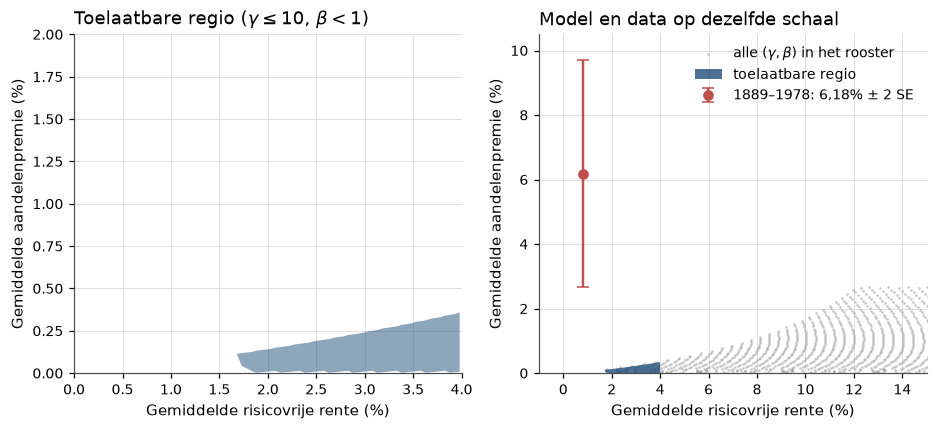

In [6]:
edges = np.linspace(0, 0.04, 81)
centres = (edges[:-1] + edges[1:]) / 2
bins = np.digitize(rf_grid[admissible], edges) - 1
upper = np.array([prem_grid[admissible][bins == k].max() if np.any(bins == k) else np.nan for k in range(80)])
lower = np.array([prem_grid[admissible][bins == k].min() if np.any(bins == k) else np.nan for k in range(80)])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].fill_between(100 * centres, 100 * lower, 100 * upper, color="C0", alpha=0.5, lw=0)
axes[0].set_xlim(0, 4)
axes[0].set_ylim(0, 2)
axes[0].set_xlabel("Gemiddelde risicovrije rente (%)")
axes[0].set_ylabel("Gemiddelde aandelenpremie (%)")
axes[0].set_title("Toelaatbare regio ($\\gamma \\leq 10$, $\\beta < 1$)")

exists = grid["exists"]
axes[1].scatter(100 * rf_grid[exists][::13], 100 * prem_grid[exists][::13], s=1, color="C7", alpha=0.3,
                label="alle $(\\gamma, \\beta)$ in het rooster")
axes[1].fill_between(100 * centres, 100 * lower, 100 * upper, color="C0", alpha=0.8, lw=0,
                     label="toelaatbare regio")
axes[1].errorbar([0.80], [6.18], yerr=[[2 * 1.76], [2 * 1.76]], fmt="o", color="C1", capsize=4,
                 label="1889–1978: 6,18% $\\pm$ 2 SE")
axes[1].set_xlim(-1, 15)
axes[1].set_ylim(0, 10.5)
axes[1].set_xlabel("Gemiddelde risicovrije rente (%)")
axes[1].set_ylabel("Gemiddelde aandelenpremie (%)")
axes[1].set_title("Model en data op dezelfde schaal")
axes[1].legend(loc="upper right")
plt.show()

:::{figure} #cel-equity-premium-puzzle-regio
:label: fig-equity-premium-puzzle-regio
:width: 100%

Links: de toelaatbare regio van Mehra en Prescott, nagerekend. Met een rente
tussen nul en vier procent komt de premie nergens boven een derde procentpunt.
Rechts: alle evenwichten met $\gamma \le 10$. De premie groeit alleen samen met de
rente, en ook de onderkant van het 95%-interval rond de historische premie ligt
een orde van grootte boven de regio.
:::

Het rooster geeft 0,36% tegen de gepubliceerde 0,35%; het verschil komt van de
fijnheid van het rooster. Het rechterpaneel toont de risicovrije-rentepuzzel
voordat Weil haar een naam gaf: de evenwichten liggen op een smalle band van
linksonder naar rechtsboven, en geen combinatie van voorkeuren heft de premie op
zonder de rente mee te nemen.

### Hoe zeker is de puzzel?

De foutbalk in het rechterpaneel verdient een eigen experiment. De historische
premie heeft een standaardfout van 1,76 procentpunt ([](#thm-rendementen-se)). Hoe
veel risicoaversie zou een onderzoeker met negentig jaar data *schatten* als de
werkelijke premie 3% of 6% is? We simuleren tienduizend steekproeven van negentig
jaar uit een wereld met bivariaat normale consumptiegroei en excess rendementen:
$\sigma(\Delta c) = 3{,}57\%$ en $\sigma(R^e) = 16{,}67\%$ (Mehra en Prescott,
tabel 1) en een correlatie van 0,37, de waarde die volgt uit tabel 1 van
Kocherlakota ($0{,}00219/\sqrt{0{,}0274 \cdot 0{,}00127}$) {cite}`Kocherlakota1996`.
Per steekproef schatten we $\hat\gamma = \overline{R^e}/\widehat{\Cov}(\Delta c, R^e)$,
de maatstaf die Campbell RRA(1) noemt.

In [7]:
n_sim, n_years = 10_000, 90
sd_c, sd_e, corr_ce = 0.0357, 0.1667, 0.37
cov_true = corr_ce * sd_c * sd_e

sim_rows, gamma_draws = {}, {}
for premium_true in (0.03, 0.06):
    z_c = rng.standard_normal((n_sim, n_years))
    z_e = corr_ce * z_c + np.sqrt(1 - corr_ce**2) * rng.standard_normal((n_sim, n_years))
    dc = 0.0183 + sd_c * z_c
    excess = premium_true + sd_e * z_e
    premium_hat = excess.mean(axis=1)
    cov_hat = ((dc - dc.mean(axis=1, keepdims=True)) * (excess - premium_hat[:, None])).sum(axis=1) / (n_years - 1)
    gamma_hat = premium_hat / cov_hat
    gamma_draws[premium_true] = gamma_hat
    q = np.percentile(gamma_hat, [2.5, 50, 97.5])
    sim_rows[f"ware premie {premium_true:.0%}"] = {
        "ware gamma": premium_true / cov_true,
        "premie 2.5%": 100 * np.percentile(premium_hat, 2.5),
        "premie 97.5%": 100 * np.percentile(premium_hat, 97.5),
        "gamma-dak 2.5%": q[0], "gamma-dak mediaan": q[1], "gamma-dak 97.5%": q[2],
        "P(gamma-dak <= 10)": np.mean(gamma_hat <= 10),
    }
pd.DataFrame(sim_rows).T.round(3)

,ware gamma,premie 2.5%,premie 97.5%,gamma-dak 2.5%,gamma-dak mediaan,gamma-dak 97.5%,P(gamma-dak <= 10)
ware premie 3%,13.624,-0.422,6.379,-2.001,13.523,42.580,0.340
ware premie 6%,27.249,2.636,9.482,10.259,27.390,70.678,0.023


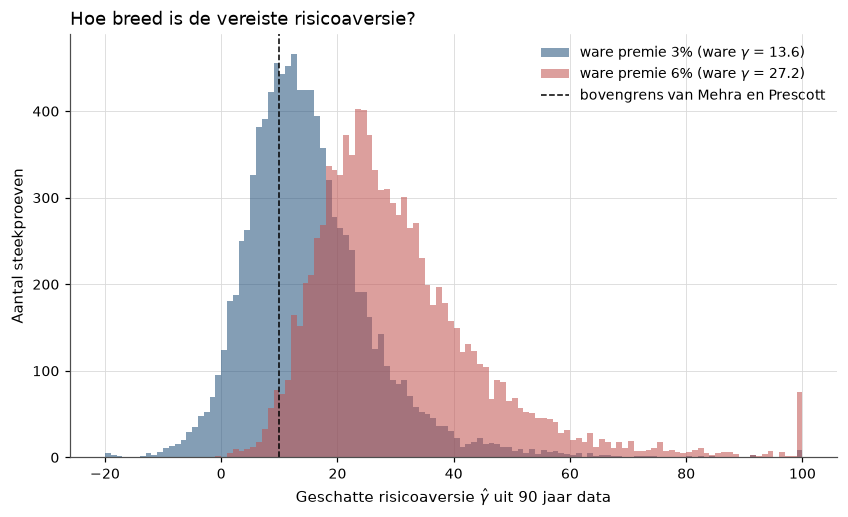

In [8]:
fig, ax = plt.subplots()
bins_g = np.linspace(-20, 100, 121)
for k, (premium_true, draws) in enumerate(gamma_draws.items()):
    ax.hist(np.clip(draws, -20, 100), bins=bins_g, alpha=0.55, color=f"C{k}",
            label=f"ware premie {100 * premium_true:.0f}% (ware $\\gamma$ = {premium_true / cov_true:.1f})")
ax.axvline(10, color="black", ls="--", lw=1, label="bovengrens van Mehra en Prescott")
ax.set_xlabel("Geschatte risicoaversie $\\hat\\gamma$ uit 90 jaar data")
ax.set_ylabel("Aantal steekproeven")
ax.set_title("Hoe breed is de vereiste risicoaversie?")
ax.legend()
plt.show()

:::{figure} #cel-equity-premium-puzzle-onzeker
:label: fig-equity-premium-puzzle-onzeker
:width: 90%

De risicoaversie die een onderzoeker uit negentig jaar data zou afleiden, in een
wereld waarin de ware premie 3% respectievelijk 6% is. De verdelingen overlappen
sterk: dezelfde steekproef past bij een ware $\gamma$ rond de dertien en rond de
zevenentwintig. Maar ook in de wereld met 3% premie ligt het grootste deel van de
massa boven de tien.
:::

Twee conclusies, in tegengestelde richting. De eerste is de nederigheid van het
2%-motief: de puzzel is niet "$\gamma = 48$". In een wereld met 6% loopt het
95%-interval van de geschatte premie van ongeveer 2,6 tot 9,5 procent, en dat van
$\hat\gamma$ van ongeveer tien tot zeventig. De covariantie is een tweede moment en
redelijk gemeten; de onzekerheid komt vooral uit het gemiddelde. De tweede
conclusie is dat de puzzel die onzekerheid overleeft. Ook als de werkelijke premie
de helft is van de gemeten premie, valt $\hat\gamma$ in twee derde van de
steekproeven boven de tien, en ligt de ware waarde ruim boven wat Mehra en
Prescott toelieten. Kocherlakota maakte hetzelfde punt formeel: op 1889–1978 is
de gemiddelde Euler-fout van aandelen tegenover T-bills significant positief "for
all values of $\alpha$ less than or equal to 8.5" (p. 49) {cite}`Kocherlakota1996`.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Rajnish Mehra en Edward C. Prescott, *The Equity Premium: A Puzzle*,
Journal of Monetary Economics 1985 {cite}`MehraPrescott1985`; Lars Peter Hansen en
Ravi Jagannathan, *Implications of Security Market Data for Models of Dynamic
Economies*, Journal of Political Economy 1991 {cite}`HansenJagannathan1991`.

**Wat.** (1) Tabel 1 van Mehra en Prescott (p. 147), rij 1889–1978: reële rente
0,80% (SE 0,60), premie 6,18% (SE 1,76), reëel S&P-rendement 6,98% (SE 1,74),
consumptiegroei 1,83% met standaarddeviatie 3,57; het maximum van 0,35% uit hun
figuur 4 rekenden we hierboven al na. (2) De Hansen-Jagannathan-grens met de
consumptie-SDF erin, zoals in hun figuur 1 (p. 228), hier voor $\gamma = 1, \dots, 50$.

**Data hier.** Shillers maanddata via `hap.data.shiller()` (S&P-prijs, dividend,
CPI), jaargemiddeld; `Rfree` uit `hap.data.goyal_welch("annual")`; reële
consumptie per hoofd van niet-duurzame goederen en diensten uit FRED via
`hap.data.fred` (`PCNDA`, `PCESVA`, `DNDGRG3A086NBEA`, `DSERRG3A086NBEA`,
`B230RC0A052NBEA`), vanaf 1929; en voor de grens de marktfactor, de T-bill en de
25 size/BM-portefeuilles van French via `hap.data.french`, per kalenderjaar,
gedefleerd met Shillers CPI, 1930–2025.

**Verschil met het origineel.** Mehra en Prescott gebruikten de data van Grossman
en Shiller: prijzen gedefleerd met de consumptiedeflator,
Kuznets-Kendrick-USNIA-consumptie vanaf 1889, en commercial paper en treasury
certificates vóór de T-bills. Wij defleren met de CPI, nemen de korte rente van
Goyal en Welch, en hebben consumptie pas vanaf 1929: de consumptiemomenten van
1889–1928 zijn met gratis data niet te reconstrueren. Hansen en Jagannathan
gebruikten jaardata 1891–1985 met aandelen en obligaties, en ook een grens met
positiviteitsrestrictie; wij niet.

**Verwachte afwijking.** De premie over 1889–1978 moet binnen een half
procentpunt van 6,18 liggen met een standaardfout van ongeveer 1,8, en de reële
rente binnen drie tienden van 0,80. Geen consumptie-SDF met $\gamma \le 10$ mag
binnen een van de grenzen vallen. De Sharpe-grens van het marktrendement mag pas
bij een $\gamma$ ruim boven de tien gehaald worden, met een impliciete reële rente
boven de twintig procent; grenzen die ook de T-bill of de 25 portefeuilles moeten
prijzen, moeten strenger zijn. Valt een SDF met $\gamma \le 5$ binnen een grens,
dan zit er een fout in de code.
```

### Tabel 1 van Mehra en Prescott

Mehra en Prescott (p. 148) berekenden het jaarrendement uit jaargemiddelde
prijzen. Shillers dividendkolom is een voortschrijdende twaalfmaandssom; het
jaargemiddelde ervan over $t+1$ meet de dividenden die tussen de twee gemiddelde
prijsdata zijn uitgekeerd.

In [9]:
shiller = hap_data.shiller()
year = shiller.index.year
price = shiller["price"].groupby(year).mean()            # annual average price (MP series P)
cpi = shiller["cpi"].groupby(year).mean()
dividend = shiller["dividend"].groupby(year).mean()      # trailing 12m dividends, averaged over the year
rfree = hap_data.goyal_welch("annual")["Rfree"]
rfree.index = rfree.index.year

inflation = cpi.shift(-1) / cpi
mp_annual = pd.DataFrame(
    {
        "S&P reëel": (price.shift(-1) + dividend.shift(-1)) / price / inflation - 1,
        "risicovrij reëel": (1 + rfree) / inflation - 1,
    }
).loc[1889:2024].dropna()
mp_annual["premie"] = mp_annual["S&P reëel"] - mp_annual["risicovrij reëel"]


def moments(frame):
    n = len(frame)
    return pd.DataFrame({"gemiddelde": frame.mean(), "std.dev.": frame.std(),
                         "SE": frame.std() / np.sqrt(n)}) * 100


published = pd.DataFrame(
    {"gemiddelde": [0.80, 6.18, 6.98], "std.dev.": [5.67, 16.67, 16.54], "SE": [0.60, 1.76, 1.74]},
    index=["risicovrij reëel", "premie", "S&P reëel"],
)
table1 = pd.concat(
    {
        "MP 1985, 1889-1978": published,
        "hier, 1889-1978": moments(mp_annual.loc[1889:1978]),
        f"hier, 1889-{mp_annual.index[-1]}": moments(mp_annual),
    },
    axis=1,
).loc[["risicovrij reëel", "premie", "S&P reëel"]]
table1.round(2)

MP 1985, 1889-1978                hier, 1889-1978           \
                         gemiddelde std.dev.    SE      gemiddelde std.dev.   
risicovrij reëel               0.80     5.67  0.60            0.75     5.81   
premie                         6.18    16.67  1.76            6.22    16.82   
S&P reëel                      6.98    16.54  1.74            6.97    16.93   

                       hier, 1889-2024                 
                    SE      gemiddelde std.dev.    SE  
risicovrij reëel  0.61            0.82     5.04  0.43  
premie            1.77            6.92    15.68  1.34  
S&P reëel         1.78            7.74    15.77  1.35

De replicatie ligt dicht bij het origineel: een premie van 6,22% tegen 6,18% met
een standaardfout van 1,77 tegen 1,76, een reële rente van 0,75% tegen 0,80%, en
een S&P-rendement van 6,97% tegen 6,98%. Over de volledige steekproef tot 2024 is
de premie groter, bijna zeven procentpunt, met een standaardfout die door 46 extra
jaren van 1,8 naar 1,3 is gezakt — langzaam, zoals $1/\sqrt{T}$ voorspelt. Een halve
eeuw nieuwe data heeft de puzzel verscherpt. Mehra rapporteerde in 2003 voor
1889–2000 6,9 procentpunt, voor 1926–2000 8,0 en voor 1947–2000 7,8 (zijn tabel 1)
{cite}`Mehra2003`.

### Consumptie en de vereiste risicoaversie

In [10]:
def fred_series(code):
    series = hap_data.fred(code)[code]
    series.index = series.index.year
    return series

# real per-capita nondurables + services (units irrelevant: only growth is used)
real_cons = (fred_series("PCNDA") / fred_series("DNDGRG3A086NBEA")
             + fred_series("PCESVA") / fred_series("DSERRG3A086NBEA")) / fred_series("B230RC0A052NBEA")

# MP timing: the return from average price t to t+1 is paired with growth c_{t+1} / c_t
cons_growth = (real_cons.shift(-1) / real_cons - 1).rename("consumptiegroei")
joint = mp_annual.join(cons_growth, how="inner").dropna()

rows_c = {}
for label, frame in {"1929-1978": joint.loc[:1978], f"1929-{joint.index[-1]}": joint}.items():
    dc, ex = frame["consumptiegroei"], frame["premie"]
    cov = np.cov(dc, ex)[0, 1]
    rows_c[label] = {
        "jaren": len(frame),
        "gem. groei (%)": 100 * dc.mean(), "std. groei (%)": 100 * dc.std(), "autocorr. groei": dc.autocorr(),
        "corr(groei, premie)": dc.corr(ex),
        "RRA(1) = premie/cov": ex.mean() / cov,
        "RRA(2) = premie/(sd sd)": ex.mean() / (dc.std() * ex.std()),
    }
rows_c["MP 1985, 1889-1978"] = {"jaren": 90, "gem. groei (%)": 1.83, "std. groei (%)": 3.57,
                               "autocorr. groei": -0.14}
pd.DataFrame(rows_c).T.round(3)

,jaren,gem. groei (%),std. groei (%),autocorr. groei,"corr(groei, premie)",RRA(1) = premie/cov,RRA(2) = premie/(sd sd)
1929-1978,50.0,2.074,2.579,0.486,0.590,21.973,12.963
1929-2024,96.0,1.876,2.179,0.367,0.512,39.819,20.396
"MP 1985, 1889-1978",90.0,1.830,3.570,-0.140,NaN,NaN,NaN


Consumptie vanaf 1929 is gladder dan de reeks die Mehra en Prescott vanaf 1889
hadden, en door de Depressie en de oorlog positief in plaats van licht negatief
geautocorreleerd. De risicoaversie uit de gemeten covariantie (RRA(1)) ligt in de
tientallen; ook met een correlatie van één (RRA(2)) is ze groter dan tien —
dezelfde orde van grootte als Campbells 20,9 en 10,4 voor 1891–1994.

### De Hansen-Jagannathan-grens

We gebruiken kalenderjaarrendementen van French, gedefleerd met de decemberwaarde
van de CPI, gekoppeld aan consumptiegroei in hetzelfde jaar. De SDF-kandidaten zijn
$m_t = \beta\,(c_t/c_{t-1})^{-\gamma}$ met $\beta = 0{,}95$, de waarde van Hansen en
Jagannathan; $\sigma(m)/\E[m]$ hangt niet van $\beta$ af. We vergelijken drie
grenzen: de Sharpe-grens [](#eq-equity-premium-puzzle-hj) van alleen het excess
marktrendement, en de frontier [](#eq-equity-premium-puzzle-frontier) voor markt
plus T-bill en voor de 25 portefeuilles plus T-bill.

In [11]:
ff3 = hap_data.french("F-F_Research_Data_Factors")
ff25 = hap_data.french("25_Portfolios_5x5")


def calendar_year(frame):
    return (1 + frame).groupby(frame.index.year).prod()


dec_cpi = shiller["cpi"][shiller.index.month == 12]
dec_cpi.index = dec_cpi.index.year
hj_data = pd.concat(
    [
        (real_cons / real_cons.shift(1)).rename("gc"),
        (dec_cpi / dec_cpi.shift(1)).rename("infl"),
        calendar_year(ff3[["RF"]]),
        calendar_year((ff3["Mkt-RF"] + ff3["RF"]).rename("Mkt")),
        calendar_year(ff25),
    ],
    axis=1,
).loc[1930:].dropna()

real_gross = hj_data.drop(columns=["gc", "infl"]).div(hj_data["infl"], axis=0)   # gross real returns
market_bill = real_gross[["Mkt", "RF"]]
ff25_bill = real_gross.drop(columns="Mkt")
excess_mkt = real_gross["Mkt"] - real_gross["RF"]
sharpe_mkt = excess_mkt.mean() / excess_mkt.std()
print(f"{hj_data.index[0]}-{hj_data.index[-1]}, {len(hj_data)} jaar; Sharpe-ratio markt = {sharpe_mkt:.3f}, "
      f"gem. reële T-bill = {100 * (real_gross['RF'].mean() - 1):.2f}%")

beta_hj = 0.95
gamma_hj = np.arange(1, 51)
sdf = np.array([beta_hj * hj_data["gc"] ** (-g) for g in gamma_hj])
mean_m, sd_m = sdf.mean(axis=1), sdf.std(axis=1, ddof=1)
bound_mkt = hap.stats.hansen_jagannathan_bound(market_bill, mean_m)["sigma_m_min"].to_numpy()
bound_25 = hap.stats.hansen_jagannathan_bound(ff25_bill, mean_m)["sigma_m_min"].to_numpy()

sdf_table = pd.DataFrame(
    {"E[m]": mean_m, "sigma(m)/E[m]": sd_m / mean_m, "impliciete R^f (%)": 100 * (1 / mean_m - 1),
     "binnen Sharpe-grens": sd_m / mean_m >= sharpe_mkt,
     "grens markt+bill": bound_mkt, "binnen markt+bill": sd_m >= bound_mkt,
     "grens 25+bill": bound_25, "binnen 25+bill": sd_m >= bound_25},
    index=pd.Index(gamma_hj, name="gamma"),
)
first_sharpe = gamma_hj[sdf_table["binnen Sharpe-grens"].to_numpy()].min()
first_mkt = gamma_hj[sdf_table["binnen markt+bill"].to_numpy()].min()
first_25 = gamma_hj[sdf_table["binnen 25+bill"].to_numpy()].min()
print(f"eerste gamma binnen de grens: Sharpe {first_sharpe}, markt + T-bill {first_mkt}, "
      f"25 portefeuilles + T-bill {first_25}")
sdf_table.loc[[1, 5, 10, 15, 20, 30, 40, 42, 43, 45, 50]].round(3)

1930-2025, 96 jaar; Sharpe-ratio markt = 0.430, gem. reële T-bill = 0.23%
eerste gamma binnen de grens: Sharpe 15, markt + T-bill 42, 25 portefeuilles + T-bill 43


,E[m],sigma(m)/E[m],impliciete R^f (%),binnen Sharpe-grens,grens markt+bill,binnen markt+bill,grens 25+bill,binnen 25+bill
gamma,,,,,,,,
1,0.933,0.022,7.188,False,1.753,False,2.654,False
5,0.872,0.118,14.677,False,3.387,False,4.794,False
10,0.811,0.263,23.242,False,5.029,False,6.994,False
15,0.767,0.453,30.300,True,6.223,False,8.602,False
20,0.741,0.708,35.040,True,6.956,False,9.591,False
30,0.746,1.513,34.078,True,6.811,False,9.396,False
40,0.864,2.808,15.756,True,3.607,False,5.087,False
42,0.908,3.120,10.190,True,2.430,True,3.530,False
43,0.933,3.281,7.227,True,1.762,True,2.665,True


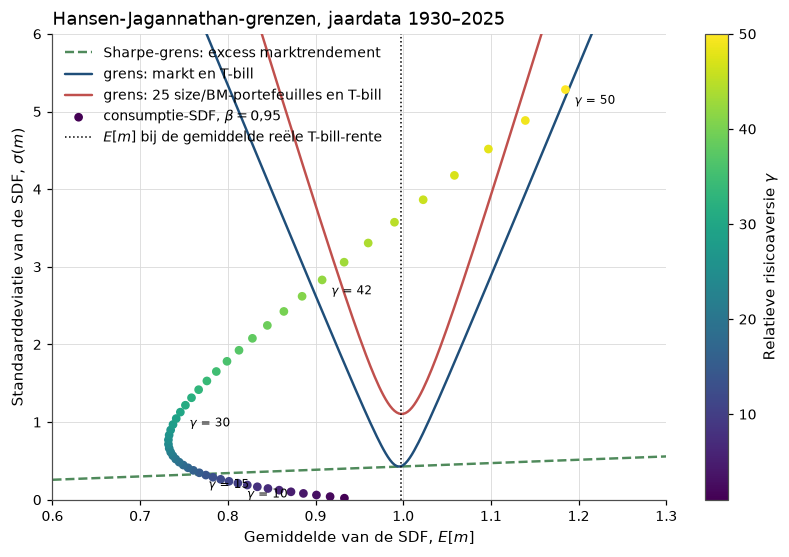

In [12]:
v_grid = np.linspace(0.6, 1.3, 281)
frontier_mkt = hap.stats.hansen_jagannathan_bound(market_bill, v_grid)
frontier_25 = hap.stats.hansen_jagannathan_bound(ff25_bill, v_grid)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(v_grid, sharpe_mkt * v_grid, color="C2", ls="--", label="Sharpe-grens: excess marktrendement")
ax.plot(v_grid, frontier_mkt["sigma_m_min"], color="C0", label="grens: markt en T-bill")
ax.plot(v_grid, frontier_25["sigma_m_min"], color="C1", label="grens: 25 size/BM-portefeuilles en T-bill")
points = ax.scatter(mean_m, sd_m, c=gamma_hj, cmap="viridis", s=22, zorder=3,
                    label="consumptie-SDF, $\\beta = 0{,}95$")
for g in (10, first_sharpe, 30, first_mkt, 50):
    ax.annotate(f"$\\gamma$ = {g}", (mean_m[g - 1], sd_m[g - 1]), textcoords="offset points",
                xytext=(6, -10), fontsize=8)
ax.axvline(1 / real_gross["RF"].mean(), color="black", ls=":", lw=1,
           label="$E[m]$ bij de gemiddelde reële T-bill-rente")
fig.colorbar(points, ax=ax, label="Relatieve risicoaversie $\\gamma$")
ax.set_xlim(0.6, 1.3)
ax.set_ylim(0, 6)
ax.set_xlabel("Gemiddelde van de SDF, $E[m]$")
ax.set_ylabel("Standaarddeviatie van de SDF, $\\sigma(m)$")
ax.set_title("Hansen-Jagannathan-grenzen, jaardata 1930–2025")
ax.legend(loc="upper left")
plt.show()

:::{figure} #cel-equity-premium-puzzle-hj
:label: fig-equity-premium-puzzle-hj
:width: 100%

Elke SDF die de activa correct prijst, ligt boven de grens. De consumptie-SDF
schuift bij toenemende $\gamma$ eerst vooral naar links: meer risicoaversie
verlaagt het gemiddelde van $m$, dus verhoogt de rente, zonder veel volatiliteit
toe te voegen. De Sharpe-grens wordt gehaald waar de rente rond de dertig procent
ligt. De grenzen met de T-bill zijn smalle V's rond de stippellijn; die haalt de
consumptie-SDF pas als de jaren met consumptiedalingen uit de Depressie het
gemiddelde van $m$ weer omhoog trekken.
:::

De verwachting uit het replicatieblok komt uit, en de drie grenzen vertellen samen
het hele verhaal. Geen consumptie-SDF met $\gamma \le 10$ ligt binnen een grens.
Wie alleen het excess marktrendement laat prijzen, heeft $\gamma = 15$ nodig, en
daar is de impliciete reële rente dertig procent: de equity premium puzzle. Wie de
SDF óók de T-bill laat prijzen, eist bovendien een gemiddelde van $m$ vlak bij
$1/R^f$, en dan komt de consumptie-SDF pas bij $\gamma$ in de veertig binnen de
grens, op het terugbuigende stuk van de curve, waar de impliciete rente tussen
$\gamma = 40$ en $50$ omslaat van ruim vijftien naar min vijftien procent: de
risicovrije-rentepuzzel in de taal van Hansen en Jagannathan. De 25 portefeuilles
vergen nauwelijks meer, maar hun grens is door overfitting ook het minst
betrouwbaar.

Het terugbuigen is geen oplossing maar een eigenschap van de steekproef: bij zulke
$\gamma$ bepalen een paar Depressiejaren het gemiddelde van $m$. Hansen en
Jagannathan zagen hetzelfde (p. 250): in maanddata zonder "bad events" buigt de
curve pas om bij $|\gamma|$ rond honderd, en een steekproef zonder rampen kan de
volatiliteit van $m$ in de populatie sterk onderschatten — de observatie waarop
Rietz zijn verklaring bouwde.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Kwalitatief alles wat het moest verklaren: aandelen
renderen meer dan obligaties omdat ze slecht betalen als consumptie tegenvalt, de
rente is hoger als groei verwacht wordt, en de discontofactor is groot in slechte
tijden. Mehra en Prescott noemden hun toets zelf "not very demanding" — een
exercitie in orde van grootte — en juist daardoor is de uitkomst robuust. De puzzel
overleeft andere groeiprocessen, leverage (p. 157–158), een halve eeuw extra data
en andere landen: in Campbells internationale tabellen is de risicoaversie uit de
gemeten covariantie "usually many times greater than 10" {cite}`Campbell1999`, zijn
handboekhoofdstuk uit 2003 werkt dat bewijs verder uit {cite}`Campbell2003`, en
Siegel en Thaler vonden dat de puzzel "exists in many countries, over long time
periods, and does not seem to be explained by survivorship bias"
{cite}`SiegelThaler1997`.

**Waar het breekt.** Op getallen die we zelf hebben nagerekend: met $\gamma \le 10$
en een rente tussen nul en vier procent is de grootste premie 0,36 procentpunt,
tegen 6,22 in de data van 1889–1978 en bijna 7 tot 2024. Zonder model zegt de
Hansen-Jagannathan-grens hetzelfde: de consumptie-SDF haalt de Sharpe-ratio van de
markt pas bij $\gamma = 15$, met een impliciete rente van dertig procent, en de
grens die ook de T-bill laat prijzen pas bij $\gamma$ in de veertig. De simulatie
laat zien dat de standaardfout van de premie de omvang van de puzzel onzeker
maakt, maar hem niet opheft.

**Risico of vergissing?** De Chicago-lezing: de premie is een echte risicopremie,
maar het risico zit in een deel van de verdeling dat negentig jaar Amerikaanse data
nauwelijks laten zien, of in voorkeuren die rijker zijn dan CRRA. Rietz stelde in
1988 voor dat een kleine kans op een zeer grote consumptiedaling de premie draagt
{cite}`Rietz1988`; Mehra vatte dat samen als "a one in hundred chance of a 25%
decline in consumption" bij een risicoaversie van tien, en merkte op dat de reële
rente dan tegen de kans op een ramp in zou moeten bewegen, wat hij niet terugzag
{cite}`Mehra2003`. De Yale-lezing: beleggers zijn niet de consumptie-afvlakkende
agent van het model; ze zijn verliesavers, kijken te vaak naar hun portefeuille of
vergissen zich over de verdeling van rendementen. Siegel en Thaler concludeerden
"that it is difficult to explain the equity premium without incorporating some kind
of irrationality" {cite}`SiegelThaler1997`. Beide lezingen verklaren het gemiddelde.
Wat ze zou scheiden — de kans op rampen, of het risico dat beleggers werkelijk
voelen — is precies het soort grootheid dat met een eeuw data niet te meten is.

**Wat er daarna kwam.** De grens van Hansen en Jagannathan hangt af van welke activa
je erin stopt, en dus van wat "de markt" is; dat die keuze een theorie ontoetsbaar
kan maken, liet Roll in 1977 zien — het onderwerp van [](#03-14-roll).

Noteer de epistemische status. In [](#03-12-consumptie-capm) werd het consumption
CAPM verworpen door een toets; hier wordt het *overtroffen* door een feit. Mehra en
Prescott schreven dat het falen "hinges not on the acceptance/rejection of a
statistical hypothesis but on its inability to generate average returns even close
to those observed" (p. 158). Vanaf hier is de equity premium een meetlat waaraan
theorieën zich moeten meten; de grote antwoorden — rampen, gewoontes,
langetermijnrisico — komen terug in [](#05-27-drie-antwoorden), en de grens van
Hansen en Jagannathan wordt het gereedschap waarmee ze worden beoordeeld in
[](#05-26-sdf-unificatie).

## Oefeningen

:::{exercise}
:label: ex-equity-premium-puzzle-1

**Het mes van Mehra.** Gebruik de lognormale iid-economie met leverage één en de
momenten $\E[x] = 1{,}018$, $\sigma(x) = 0{,}036$, $R^f = 1{,}008$ en
$\E[R] = 1{,}0698$ (Mehra 2003, tabel 4).

1. Leid uit [](#eq-equity-premium-puzzle-lognormaal) af welke $\gamma$ en $\beta$
   de rente en het aandelenrendement exact reproduceren.
2. Laat zien dat $\partial \log R^f / \partial \gamma = \mu_x - \gamma\sigma_x^2$ en
   bereken hoeveel de rente verandert als $\gamma$ één eenheid hoger of lager is bij
   vaste $\beta$.
3. Leg uit waarom Mehra dit een "knife edge" noemt.
:::

:::{solution} ex-equity-premium-puzzle-1
:class: dropdown

**(1)** De eerste vergelijking geeft $\gamma = (\log\E[R] - \log R^f)/\sigma_x^2$, de
tweede daarna $\log\beta = -\log R^f + \gamma\mu_x - \tfrac12\gamma^2\sigma_x^2$.
**(2)** Differentiëren geeft $\mu_x - \gamma\sigma_x^2 \approx 0{,}0172 - 0{,}060 = -0{,}042$
per eenheid $\gamma$.

In [13]:
ERe_obs = 1.0698
gamma_edge = (np.log(ERe_obs) - np.log(Rf_obs)) / s2_x
log_beta_edge = -np.log(Rf_obs) + gamma_edge * mu_x - 0.5 * gamma_edge**2 * s2_x
print(f"gamma = {gamma_edge:.1f}, beta = {np.exp(log_beta_edge):.3f}   (Mehra 2003: 47.6 en 0.55)")
edge = pd.DataFrame({"gamma": gamma_edge + np.array([-1.0, 0.0, 1.0])})
edge["R^f (%)"] = 100 * (np.exp(-log_beta_edge + edge["gamma"] * mu_x - 0.5 * edge["gamma"] ** 2 * s2_x) - 1)
edge.round(2)

gamma = 47.6, beta = 0.546   (Mehra 2003: 47.6 en 0.55)


,gamma,R^f (%)
0,46.61,5.09
1,47.61,0.80
2,48.61,-3.43


**(3)** Eén eenheid $\gamma$ verschuift de reële rente met ruim vier procentpunt. De
data zijn dus met één punt in de parameterruimte te reproduceren, en dat punt
vereist $\beta = 0{,}55$: beleggers die volgend jaar half zo belangrijk vinden als
dit jaar. Wat de oefening leert: een hoge $\gamma$ "lost" de premie op door de rente
over te leveren aan een voorzorgsterm die kwadratisch is in $\gamma$, en een model
dat zo precies moet worden afgesteld, verklaart niets.
:::

:::{exercise}
:label: ex-equity-premium-puzzle-2

**De grens in deelperioden en met bootstrap.** Gebruik de jaardata van de
replicatie (`hj_data`).

1. Bereken voor 1930–1977 en 1978–2025 de Sharpe-ratio van de markt en de kleinste
   $\gamma \in \{1, \dots, 60\}$ waarvoor de consumptie-SDF
   [](#eq-equity-premium-puzzle-hj) haalt.
2. Trek voor de volledige steekproef 2000 bootstrapsteekproeven van jaren (paren van
   consumptiegroei en excess rendement) en rapporteer het 90%-interval van de
   Sharpe-ratio en van de kleinste $\gamma$.
:::

:::{solution} ex-equity-premium-puzzle-2
:class: dropdown

In [14]:
gamma_ex2 = np.arange(1, 61)


def first_gamma(gc, sharpe_ratio):
    """Smallest gamma with sd(g^-gamma)/mean(g^-gamma) >= Sharpe ratio (rows = samples)."""
    powered = gc[..., None] ** (-gamma_ex2)
    ratio = powered.std(axis=-2, ddof=1) / powered.mean(axis=-2)
    hit = ratio >= np.asarray(sharpe_ratio)[..., None]
    return np.where(hit.any(axis=-1), gamma_ex2[hit.argmax(axis=-1)], np.nan)


gc_all = hj_data["gc"].to_numpy()
ex_all = excess_mkt.to_numpy()
rows_ex2 = {}
for label, sel in {"1930-1977": hj_data.index <= 1977, "1978-2025": hj_data.index >= 1978,
                   "1930-2025": np.ones(len(hj_data), bool)}.items():
    sr = ex_all[sel].mean() / ex_all[sel].std(ddof=1)
    rows_ex2[label] = {"Sharpe-ratio": sr, "kleinste gamma": first_gamma(gc_all[sel], sr)}

draws = rng.integers(0, len(gc_all), size=(2000, len(gc_all)))
sr_boot = ex_all[draws].mean(axis=1) / ex_all[draws].std(axis=1, ddof=1)
gamma_boot = first_gamma(gc_all[draws], sr_boot)
rows_ex2["bootstrap 5%"] = {"Sharpe-ratio": np.percentile(sr_boot, 5),
                            "kleinste gamma": np.nanpercentile(gamma_boot, 5)}
rows_ex2["bootstrap 95%"] = {"Sharpe-ratio": np.percentile(sr_boot, 95),
                             "kleinste gamma": np.nanpercentile(gamma_boot, 95)}
pd.DataFrame(rows_ex2).T.round(2)

,Sharpe-ratio,kleinste gamma
1930-1977,0.341393,11.0
1978-2025,0.564482,27.0
1930-2025,0.4295,15.0
bootstrap 5%,0.254383,10.0
bootstrap 95%,0.644486,26.0


De tweede helft heeft een hogere Sharpe-ratio en veel gladdere consumptie, en vraagt
daardoor een veel hogere $\gamma$ dan de eerste, waarin de Depressie de
consumptie-SDF volatiel maakt. Het bootstrapinterval van de Sharpe-ratio is breed —
het 2%-motief — en dat van de vereiste $\gamma$ dus ook, maar zelfs de onderkant
ligt op de bovengrens van Mehra en Prescott. Wat de oefening leert: de omvang van de
puzzel hangt sterk af van welke periode je meet, het bestaan ervan niet.
:::

:::{exercise}
:label: ex-equity-premium-puzzle-3

**Een ramp in de keten van Mehra en Prescott.** Voeg aan het toy-voorbeeld een
derde toestand toe met groei $g_d = 0{,}75$. Vanuit de normale toestanden is de kans
op een ramp $\eta = 0{,}01$ (de overige kansen maal $1 - \eta$); na een ramp keert
de economie met kans $\tfrac12$ terug naar elk van de normale toestanden. Neem
$\beta = 0{,}99$.

1. Bereken de gemiddelde premie en rente voor $\gamma \in \{2, 4, 6, 8, 10\}$ met
   `mp_economy`.
2. Hoe groot is de kans dat negentig jaar geen enkele ramp bevatten?
3. Wat betekent dat voor een onderzoeker die de premie in zo'n steekproef meet?
:::

:::{solution} ex-equity-premium-puzzle-3
:class: dropdown

In [15]:
eta, g_disaster = 0.01, 0.75
growth_rietz = np.array([1.054, 0.982, g_disaster])
trans_rietz = np.array([
    [0.43 * (1 - eta), 0.57 * (1 - eta), eta],
    [0.57 * (1 - eta), 0.43 * (1 - eta), eta],
    [0.5, 0.5, 0.0],
])
rows_ex3 = {}
for gamma_val in (2, 4, 6, 8, 10):
    eco = mp_economy(gamma_val, 0.99, growth_rietz, trans_rietz)
    rows_ex3[gamma_val] = {"bestaat": bool(eco["exists"]), "E[R^f] - 1 (%)": 100 * (eco["ERf"] - 1),
                           "premie (%)": 100 * (eco["ERe"] - eco["ERf"])}
print(f"kans op 90 jaar zonder ramp: {(1 - eta) ** 90:.3f}")
pd.DataFrame(rows_ex3).T.rename_axis("gamma").round(2)

kans op 90 jaar zonder ramp: 0.405


,bestaat,E[R^f] - 1 (%),premie (%)
gamma,,,
2,True,3.441277,0.505722
4,True,4.735713,1.332219
6,True,4.348155,2.610076
8,True,1.50486,4.559651
10,True,-4.715906,7.52628


Met één procent kans per jaar op een daling van 25% stijgt de premie bij dezelfde
$\gamma$ met een veelvoud en daalt de rente: de ramp maakt obligaties waardevol als
verzekering. Bij $\gamma = 6$ is de premie al ongeveer 2,6% bij een rente van ruim
4%; bij $\gamma = 10$ is de premie ruim 7% en de rente negatief. De kans op negentig
jaar zonder ramp is $0{,}99^{90} \approx 0{,}40$. In zo'n steekproef ziet de
onderzoeker de hoge premie wel (die zit in de prijzen) maar niet het risico (dat zit
in een toestand die niet voorkwam). Wat de oefening leert: de puzzel kan een *peso
problem* zijn — risico dat in de prijzen zit maar niet in de steekproef — en daarom
is hij met gemiddelden alleen niet te beslechten; [](#05-27-drie-antwoorden) werkt
dit uit met de kalibratie van Barro {cite}`Barro2006`.
:::